# 位置情報は緯度経度で距離感を加味したいな！

★実行環境の選択

In [1]:
# VSCodeの場合
edi_flg = 1
# Googlre Colabの場合
# edi_flg = 0

In [2]:
if edi_flg == 0:
  # GoogleColabにGitHubリポジトリをクローンする用
  %cd /content/My_Python_project

  from google.colab import auth
  auth.authenticate_user()
  !git clone https://github.com/keiseki-eng/My_Python_project
  !git pull origin main



In [3]:
# import sys
# !{sys.executable} -m pip install ipykernel

In [4]:
import os
import sys
import yaml
import pandas as pd
import numpy as np
import lightgbm as lgb
import shap
import matplotlib.pyplot as plt
import japanize_matplotlib

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, KFold

# srcディレクトリをPythonの検索パスに追加
sys.path.append("/home/keiseki/JR_train_snow/30.src")

# validation.pyからsplit_timeを読み込み
from utils.validation import split_time

/home/keiseki/JR_train_snow/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
if edi_flg == 0:
  from google.colab import drive
  drive.mount('/content/drive')

In [6]:
import warnings
warnings.filterwarnings(
    "ignore",
    category=pd.errors.PerformanceWarning
)

## 01.config読み込み

In [7]:
# VSCode用
if edi_flg==1:
  conf_path = os.path.join( '../00.config/config.yaml')
  path_set = os.path.join('../00.config/path.yaml')
  with open(conf_path, 'r') as f:
    config = yaml.safe_load(f)
  with open(path_set, 'r') as f:
    path_config = yaml.safe_load(f)

# GoogleColab用
elif edi_flg==0:
  conf_path = "My_Python_project/config/config.yaml"
  path_set = "My_Python_project/config/path.yaml"
  with open(conf_path, "r") as f:
    config = yaml.safe_load(f)
  with open(path_set, "r") as f:
    path_config = yaml.safe_load(f)

In [8]:
# 定義した特徴量リストを読み込み
feature_list = config['FEATURE']['FEATURE_LIST']
# カテゴリカルカラムのリストを定義
categorical_cols = config['FEATURE']['CATEGORICAL_COLS']

# 気象データ分
locations = config["WEATHER_FEATURE"]["locations"]
variables = config["WEATHER_FEATURE"]["variables"]
hours = config["WEATHER_FEATURE"]["hours"]
w_categories = config["WEATHER_CATEGORY"]["WEATHER_CATEGORY_LIST"]

# 気象データの特徴量リストを作成
weather_feature_cols = [
    f"{location}_{variable}_{hour}"
    for location in locations
    for variable in variables
    for hour in hours
]
weather_categorical_cols = [
    f"{location}_{w_category}_{hour}"
    for location in locations
    for w_category in w_categories
    for hour in hours
]

# 積雪計データ分
snow_locations = config["SNOW_FEATURE"]["locations"]
snow_variables = config["SNOW_FEATURE"]["variables"]
snow_statistics = config["SNOW_FEATURE"]["statistics"]
snow_time_zones = config["SNOW_FEATURE"]["time_zones"]
snow_categories = config["SNOW_CATEGORY"]["SNOW_CATEGORY_LIST"]

# 積雪計データの特徴量リストを作成
snow_feature_cols = [
    f"{location}_{variable}_{statistic}_{time_zone}"
    for location in snow_locations
    for variable in snow_variables
    for statistic in snow_statistics
    for time_zone in snow_time_zones
]
snow_categorical_cols = [
    f"{location}_{snow_category}_{time_zone}"
    for location in snow_locations
    for snow_category in snow_categories
    for time_zone in snow_time_zones
]

# 通常の特徴量リストに気象データ分を追加
feature_list += weather_feature_cols
categorical_cols += weather_categorical_cols
# 通常の特徴量リストに積雪計データ分を追加
feature_list += snow_feature_cols
categorical_cols += snow_categorical_cols

# validationの分割日を設定
binary_split_date = config["binary_split_date"]

In [9]:
# 学習データ、テストデータの読み込み
train_data_path = path_config['INTERIUM_PATH']['train_data']
test_data_path = path_config['INTERIUM_PATH']['test_data']

df_train = pd.read_pickle(train_data_path)
df_test = pd.read_pickle(test_data_path)


## interaction特徴量を追加

## 05.train/valid 分割　＆　target加工

In [10]:
# feature_listに存在しないカラムがあれば、NaNで追加
fix_list = feature_list + ["年月日", "着雪有無フラグ"]
df_train = df_train.reindex(columns=fix_list)
# 時系列分析のため、train_test_splitではなくsplit_timeを使用
X_train, X_valid, y_train, y_valid, = split_time(df_train, split_col="年月日", target_col="着雪有無フラグ", split_date=binary_split_date)
# ランダム分割の場合
# X_train, X_valid, y_train, y_valid, = train_test_split(df_train, df_train["合計"], test_size=0.2, random_state=42)


train: 2016-01-19 00:00:00 ～ 2016-10-04 00:00:00
valid: 2016-10-05 00:00:00 ～ 2016-12-31 00:00:00
train件数: 11464
valid件数: 3875


## 07.モデル学習

In [11]:
# def wmae_eval(preds, train_data):
#     y_true = train_data.get_label()

#     # コンペ指定の重み
#     weights = np.abs(y_true) * 1e4 + 1

#     wmae = np.sum(weights * np.abs(y_true - preds)) / np.sum(weights)

#     return "WMAE", wmae, False

In [12]:
# 学習データの前処理:特徴量リストに限定
X_train = X_train[feature_list].copy()
X_valid = X_valid[feature_list].copy()
    
# ：object型の列をcategoryへ
cat_cols = [c for c in categorical_cols if c in X_train.columns]
# 明示的にobject型の全列もcategoryに変換（未指定のカテゴリ列がある場合に備えて）
obj_cols = X_train.select_dtypes(include=["object"]).columns.tolist()

for df in [X_train, X_valid, df_test]:
    cols = sorted(set(cat_cols + obj_cols).intersection(df.columns))
    if cols:
        df[cols] = df[cols].astype("category")

/tmp/ipykernel_3941/4221972066.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols = X_train.select_dtypes(include=["object"]).columns.tolist()


In [13]:
for col in [c for c in X_train.columns if "日照時間" in c]:
    X_train[col] = pd.to_numeric(X_train[col], errors="coerce")
    X_valid[col] = pd.to_numeric(X_valid[col], errors="coerce")


In [14]:
# LightGBM のパラメータ設定
params = config['BINARY_MODEL_PARAMS']

# LightGBM のデータセットを作成
lgb_train = lgb.Dataset(
    X_train,
    y_train,
    categorical_feature=categorical_cols
)


lgb_test = lgb.Dataset(
    X_valid,
    y_valid,
    reference=lgb_train,
    categorical_feature=categorical_cols
)


# モデルの学習
model = lgb.train(
    params,
    lgb_train,
    num_boost_round=1000,
    valid_sets=[lgb_train, lgb_test],
    callbacks=[
        lgb.early_stopping(100)
    ]
)

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[28]	training's binary_logloss: 0.0152352	valid_1's binary_logloss: 0.0253494


## 08.評価

特徴量の重要度


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

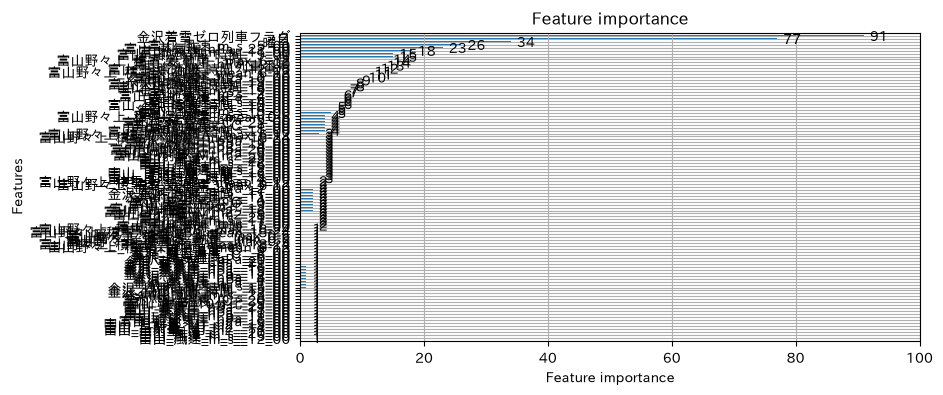

In [15]:
# 検証データで予測
y_pred = model.predict(X_valid , num_iteration=model.best_iteration)


# 特徴量の重要度
print("特徴量の重要度")
lgb.plot_importance(model, figsize=(8,4))


## 09.可視化（importance SHAP）

In [16]:

# import lightgbm as lgb
# from sklearn.model_selection import GridSearchCV

# # パラメータの探索範囲を指定
# param_grid = {
#     'num_leaves': [20, 30, 40],
#     'learning_rate': [0.01, 0.1, 0.5],
#     'max_depth': [5, 10]
# }




# # グリッドサーチCV
# gsearch = GridSearchCV(gbm, param_grid, cv=5) #cvは交差検証の回数

# # データを学習
# gsearch.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=False)])



# # 最適なパラメータとスコアを表示
# print('Best parameters found by grid search are:', gsearch.best_params_)
# print('Best score:', gsearch.best_score_)


In [17]:
# # パラメータの辞書を結合
# best_params = {**params, **gsearch.best_params_}

# # 最適パラメータでモデルを再学習
# model = lgb.LGBMClassifier(**best_params)
# model.fit(X_train, y_train)

In [18]:
#SHAP値の取得
explainer = shap.TreeExplainer(model=model)#SHAP値を取得するためのモデル作成
shap_values = explainer.shap_values(X=X_valid)#説明変数それぞれの値のSHAP値を取得する

# print(shap_values)
# print(shap_values.shape)


/home/keiseki/JR_train_snow/.venv/lib/python3.11/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


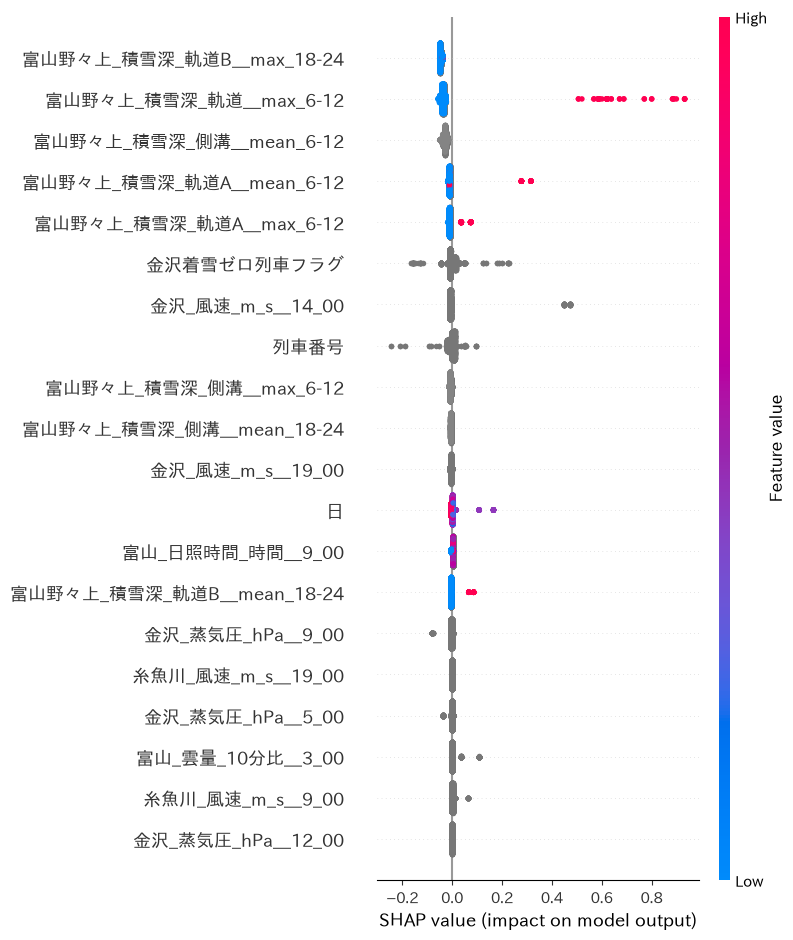

In [19]:

# 変数別の影響度の可視化
shap.initjs()
# shap.summary_plot(shap_values, X_valid, plot_type="bar", show=False)
shap.summary_plot(shap_values, X_valid, show=False)


# 0番目のデータポイントを再選択
i = 0
single_observation = X_valid.iloc[i:i+1,:]


#print(single_observation)


# Explainerを使って説明を再計算
# single_shap_values = explainer(single_observation)

# waterfallプロットの生成
# shap.waterfall_plot(single_shap_values[0])

ROC-AUC: 0.9965


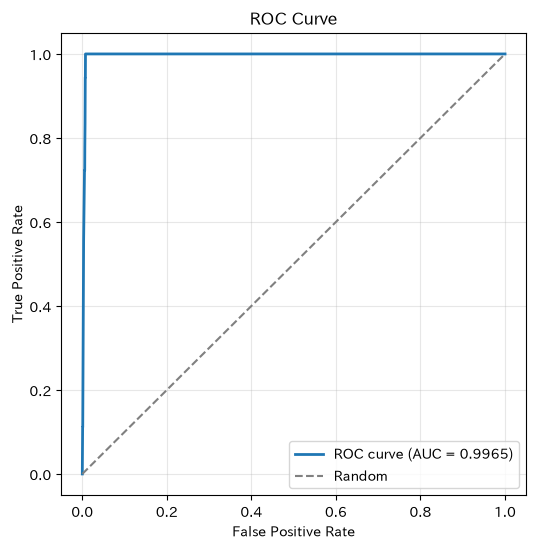

In [20]:
# ROC曲線の計算
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

# 1) 2値ラベルへ変換
# 例: 雪量が 0 より大きい = 着雪発生
y_valid_bin = (y_valid > 0).astype(int)

# 2) 予測スコアを作る
# 回帰モデルなら予測値そのものをスコアとして使う
# 分類モデルなら predict_proba(X_valid)[:, 1] を使う
if hasattr(model, "predict_proba"):
    y_score = model.predict_proba(X_valid)[:, 1]
else:
    y_score = model.predict(X_valid).astype(float)

# 3) ROC-AUC を計算
auc_score = roc_auc_score(y_valid_bin, y_score)
print(f"ROC-AUC: {auc_score:.4f}")

# 4) ROC曲線を描画
fpr, tpr, thresholds = roc_curve(y_valid_bin, y_score)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc_score:.4f})", linewidth=2)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 10.推論

In [21]:
# 特徴量の選定
# feature_columns に存在しないカラムがあれば、NaNで追加
df_test_p = df_test.reindex(columns=feature_list)

for col in [c for c in X_train.columns if "日照時間" in c]:
    df_test_p[col] = pd.to_numeric(df_test_p[col], errors="coerce")


# 予測
y_pred  = model.predict(df_test_p)

# print(y_pred)

# 予測結果の確率の分布を確認して、しきい値を決めたい！

In [22]:
# from sklearn.metrics import confusion_matrix, classification_report

# thresholds = [0.005, 0.007, 0.01, 0.015, 0.02]

# for result in fold_valid_predictions:

#     fold_idx = result["fold_index"]
#     y_true = result["y_true"]
#     y_pred_prob = result["y_pred"]

#     print("=" * 60)
#     print(f"Fold {fold_idx}")
#     print("=" * 60)

#     print("\n予測確率:")
#     print(pd.Series(y_pred_prob).describe())

#     for threshold in thresholds:

#         y_pred = (y_pred_prob >= threshold).astype(int)

#         print(f"\n--- threshold = {threshold} ---")

#         print("confusion matrix")
#         print(confusion_matrix(y_true, y_pred, labels=[0, 1]))

#         print("classification report")
#         print(
#             classification_report(
#                 y_true,
#                 y_pred,
#                 zero_division=0
#             )
#         )

In [23]:
# from sklearn.metrics import confusion_matrix, classification_report

# for threshold in [0.005, 0.007, 0.01, 0.015, 0.02]:

#     y_pred = (y_pred_prob >= threshold).astype(int)

#     print("=== confusion matrix ===")
#     print(confusion_matrix(y_valid, y_pred))

#     print("\n=== classification report ===")
#     print(classification_report(y_valid, y_pred, zero_division=0))

In [24]:

# 着雪有無予測結果の表示
df_y_pred = pd.DataFrame(y_pred)
df_test_snow_flg = pd.concat([df_test_p, df_y_pred], axis=1)


# 着雪確率のカラムはrename＋configのしきい値を見て着雪有無フラグを付与しよう！

In [25]:
df_test_snow_flg = df_test_snow_flg.rename(
    columns={
        0: '着雪確率'
    }
)

In [26]:
df_test_snow_flg.columns

Index(['年', '月', '日', '曜日', '列車番号', '金沢着雪ゼロ列車フラグ', '富山_気温_1_00', '富山_気温_2_00',
       '富山_気温_3_00', '富山_気温_4_00',
       ...
       '富山野々上_積雪深_軌道B__mean_18-24', '富山野々上_積雪深_軌道B__max_0-6',
       '富山野々上_積雪深_軌道B__max_6-12', '富山野々上_積雪深_軌道B__max_12-18',
       '富山野々上_積雪深_軌道B__max_18-24', '富山野々上_積雪深_軌道B__min_0-6',
       '富山野々上_積雪深_軌道B__min_6-12', '富山野々上_積雪深_軌道B__min_12-18',
       '富山野々上_積雪深_軌道B__min_18-24', '着雪確率'],
      dtype='str', length=1063)

In [27]:
threthold = config["thresholds"]
# しきい値以上の着雪確率を持つレコードに対し、着雪量予測フラグを付与する
df_test_snow_flg["着雪量予測フラグ"] = 0
df_test_snow_flg[df_test_snow_flg["着雪確率"]>threthold]["着雪量予測フラグ"] = 1

/tmp/ipykernel_3941/2502968230.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  df_test_snow_flg[df_test_snow_flg["着雪確率"]>threthold]["着雪量予測フラグ"] = 1


In [ ]:
df_test_snow_flg.to_pickle("/home/keiseki/JR_train_snow/20.Data/test_exist_snow_flg.pkl")